In [7]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Upload CSV dataset from your system

from google.colab import files

uploaded = files.upload()

Saving Superstoredataset.csv to Superstoredataset (2).csv


In [9]:
# Get uploaded file name

file_name = list(uploaded.keys())[0]

# Read CSV file

df = pd.read_csv(file_name)

# Display first 5 rows

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
# Display dataset shape

print("DATASET SHAPE")
print(df.shape)

# Display all column names

print("\nCOLUMN NAMES")
print(df.columns)

# Display data types of columns

print("\nDATA TYPES")
print(df.dtypes)

DATASET SHAPE
(9800, 18)

COLUMN NAMES
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

DATA TYPES
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [11]:
# Check missing/null values

print("MISSING VALUES")
print(df.isnull().sum())

MISSING VALUES
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [12]:
# Store number of rows before removing duplicates

before_rows = df.shape[0]

# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Store number of rows after removing duplicates

after_rows = df.shape[0]

# Print results

print("Rows Before:", before_rows)
print("Rows After:", after_rows)

Rows Before: 9800
Rows After: 9800


In [13]:
# Convert Order Date column into datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Create Month column

df['Month'] = df['Order Date'].dt.month_name()

# Create Year column

df['Year'] = df['Order Date'].dt.year

# Display updated dataframe

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month,Year
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,November,2017
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,November,2017
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,June,2017
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,October,2016
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,October,2016


In [14]:
# Calculate total sales

total_sales = df['Sales'].sum()

# Print total sales

print("TOTAL SALES")
print(total_sales)

TOTAL SALES
2261536.7827000003


In [15]:
# Group data by Category and calculate total sales

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Print category wise sales

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


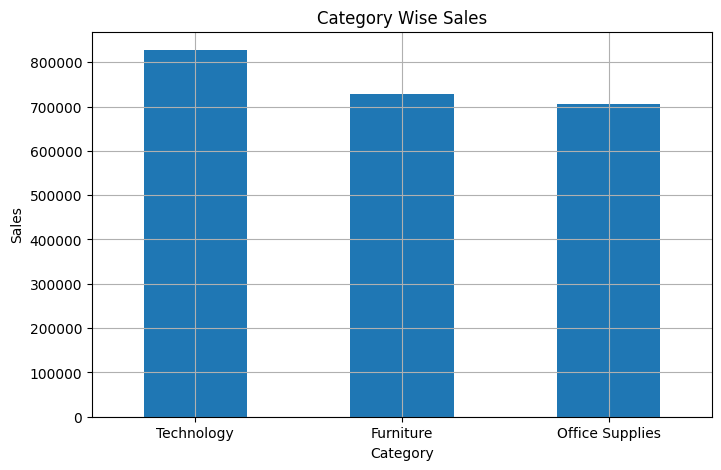

In [16]:
# Create figure size

plt.figure(figsize=(8,5))

# Create bar chart

category_sales.plot(kind='bar')

# Add chart title and labels

plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales')

# Rotate x-axis labels

plt.xticks(rotation=0)

# Add grid

plt.grid(True)

# Display chart

plt.show()

In [17]:
# Calculate sales by sub-category

sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

# Print sub-category sales

print(sub_category_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


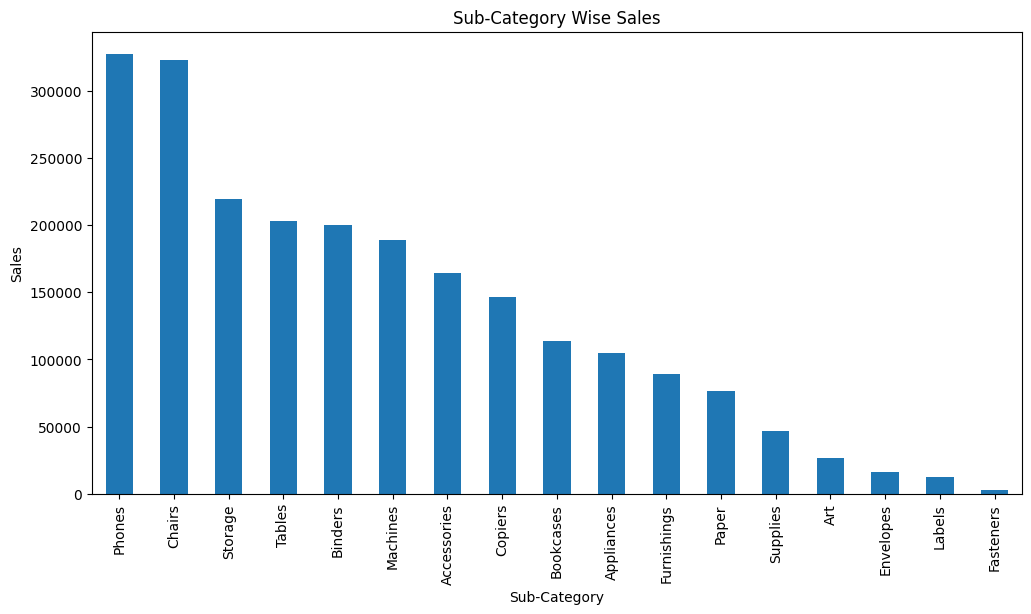

In [18]:
# Set figure size

plt.figure(figsize=(12,6))

# Create bar chart

sub_category_sales.plot(kind='bar')

# Add labels and title

plt.title('Sub-Category Wise Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')

# Rotate labels for better visibility

plt.xticks(rotation=90)

# Show chart

plt.show()

In [19]:
# Calculate region wise sales

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Print region sales

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


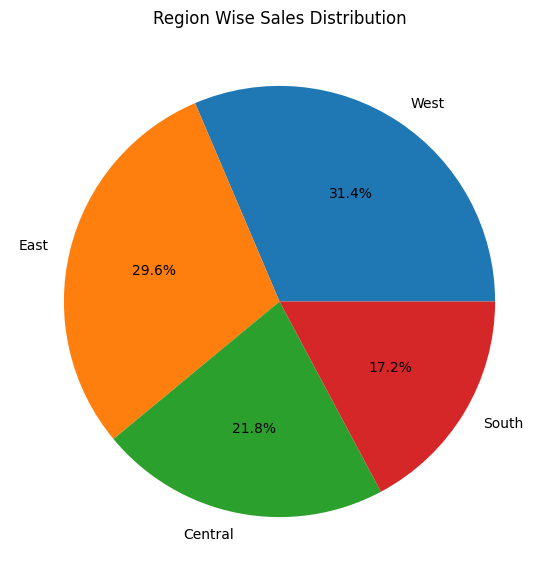

In [35]:
# Set figure size

plt.figure(figsize=(7,7))

# Create pie chart

region_sales.plot(kind='pie', autopct='%1.1f%%')

# Add title

plt.title('Region Wise Sales Distribution')

# Remove y-axis label

plt.ylabel('')

# Show chart

plt.show()

In [36]:
# Calculate top 10 states by sales

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

# Print top states

print(state_sales)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


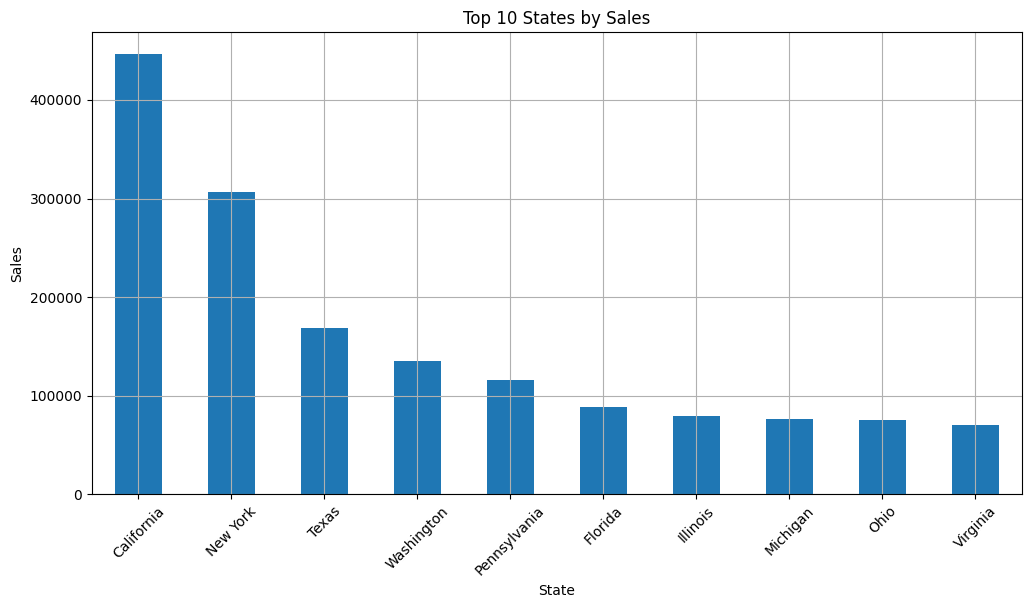

In [37]:
# Set chart size

plt.figure(figsize=(12,6))

# Create bar chart

state_sales.plot(kind='bar')

# Add title and labels

plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')

# Rotate labels

plt.xticks(rotation=45)

# Add grid

plt.grid(True)

# Display chart

plt.show()

In [38]:
# Calculate top products by sales

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Print top products

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


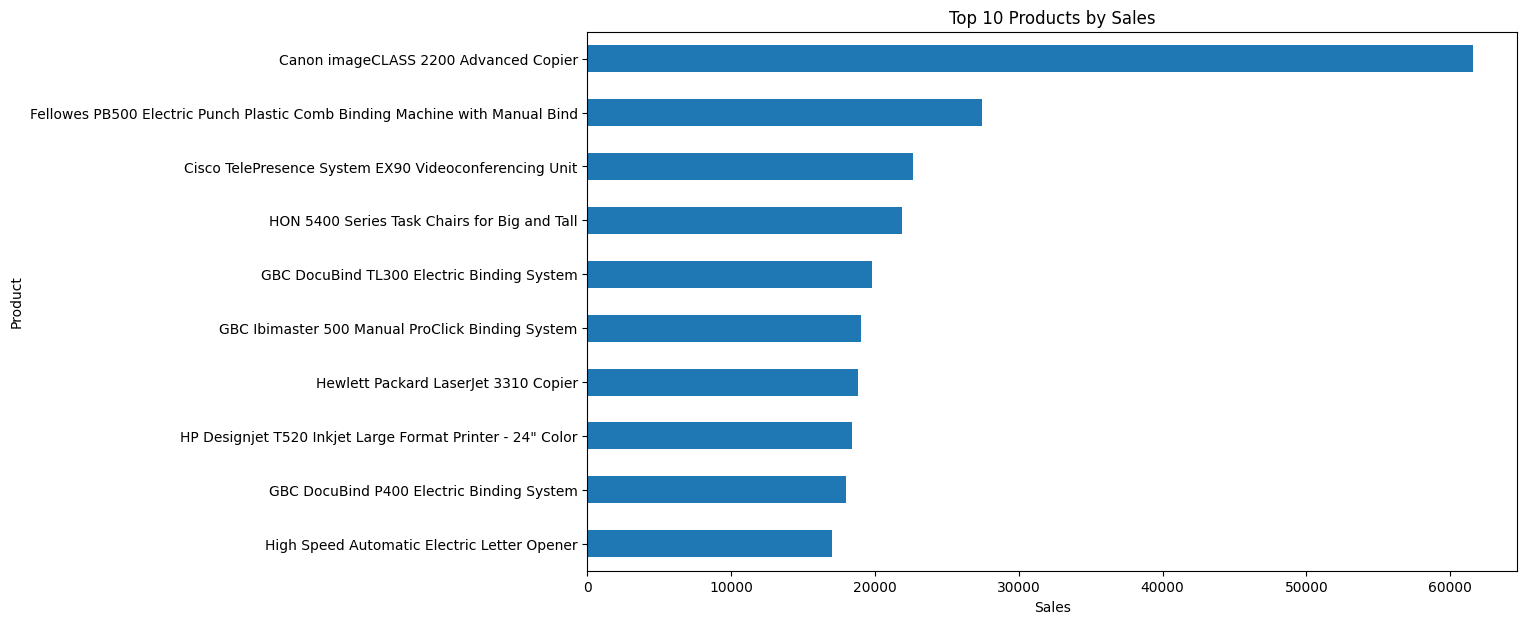

In [39]:
# Set figure size

plt.figure(figsize=(12,7))

# Create horizontal bar chart

top_products.sort_values().plot(kind='barh')

# Add title and labels

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')

# Show chart

plt.show()

In [40]:
# Calculate monthly sales

monthly_sales = df.groupby('Month')['Sales'].sum()

# Arrange months in correct order

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

# Reindex months

monthly_sales = monthly_sales.reindex(month_order)

# Print monthly sales

print(monthly_sales)

Month
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64


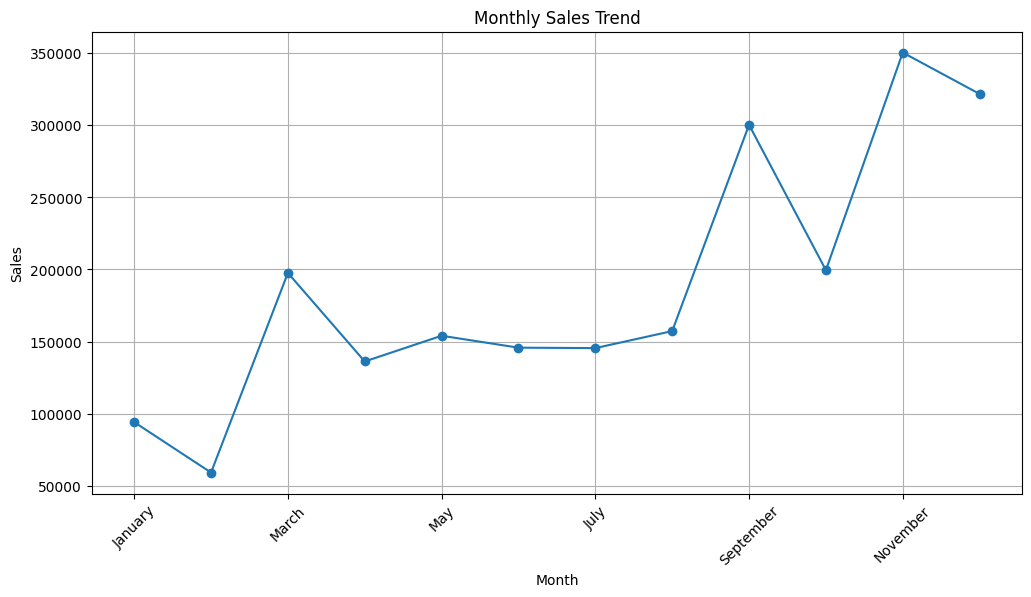

In [41]:
# Set figure size

plt.figure(figsize=(12,6))

# Create line chart

monthly_sales.plot(marker='o')

# Add title and labels

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

# Rotate labels

plt.xticks(rotation=45)

# Add grid

plt.grid(True)

# Show chart

plt.show()

In [42]:
# Calculate sales by ship mode

ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

# Print ship mode sales

print(ship_mode_sales)

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


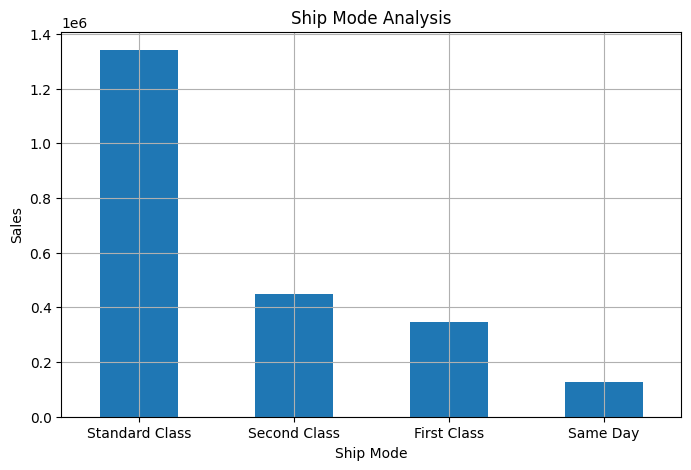

In [43]:
# Set chart size

plt.figure(figsize=(8,5))

# Create bar chart

ship_mode_sales.plot(kind='bar')

# Add title and labels

plt.title('Ship Mode Analysis')
plt.xlabel('Ship Mode')
plt.ylabel('Sales')

# Rotate labels

plt.xticks(rotation=0)

# Add grid

plt.grid(True)

# Show chart

plt.show()

In [44]:
# Calculate top customers

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Print top customers

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


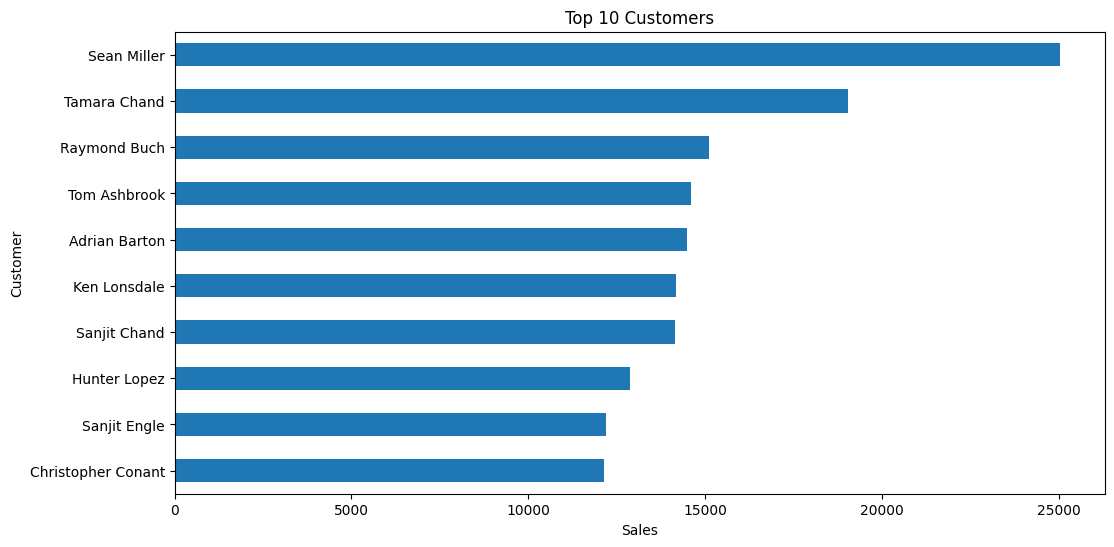

In [45]:
# Set figure size

plt.figure(figsize=(12,6))

# Create horizontal bar chart

top_customers.sort_values().plot(kind='barh')

# Add title and labels

plt.title('Top 10 Customers')
plt.xlabel('Sales')
plt.ylabel('Customer')

# Show chart

plt.show()

In [46]:
# Calculate year wise sales

year_sales = df.groupby('Year')['Sales'].sum()

# Print year wise sales

print(year_sales)

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


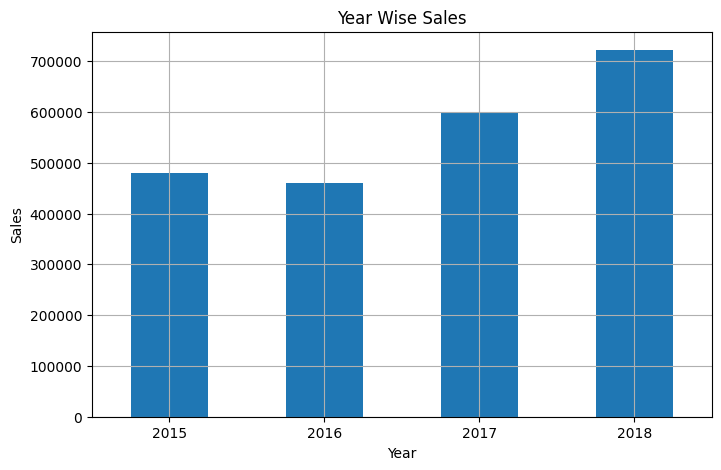

In [47]:
# Set chart size

plt.figure(figsize=(8,5))

# Create bar chart

year_sales.plot(kind='bar')

# Add title and labels

plt.title('Year Wise Sales')
plt.xlabel('Year')
plt.ylabel('Sales')

# Rotate labels

plt.xticks(rotation=0)

# Add grid

plt.grid(True)

# Display chart

plt.show()

In [48]:
# Export cleaned dataset to CSV

df.to_csv('cleaned_superstore_dataset.csv', index=False)

# Print success message

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [33]:
print("BUSINESS INSIGHTS\n")

print("Highest Sales Category:", category_sales.idxmax())

print("Best Performing Region:", region_sales.idxmax())

print("Top Selling Product:", top_products.idxmax())

print("Highest Revenue State:", state_sales.idxmax())

print("Most Preferred Ship Mode:", ship_mode_sales.idxmax())

BUSINESS INSIGHTS

Highest Sales Category: Technology
Best Performing Region: West
Top Selling Product: Canon imageCLASS 2200 Advanced Copier
Highest Revenue State: California
Most Preferred Ship Mode: Standard Class


In [34]:
print("""
PROJECT CONCLUSION

This project analyzed Superstore sales data using Python.

The analysis identified:
- Top performing categories
- Best sales regions
- High revenue products
- Customer purchasing patterns
- Monthly sales trends

Skills Demonstrated:
- Data Cleaning
- Exploratory Data Analysis
- Business Analytics
- Data Visualization
- Insight Generation
""")


PROJECT CONCLUSION

This project analyzed Superstore sales data using Python.

The analysis identified:
- Top performing categories
- Best sales regions
- High revenue products
- Customer purchasing patterns
- Monthly sales trends

Skills Demonstrated:
- Data Cleaning
- Exploratory Data Analysis
- Business Analytics
- Data Visualization
- Insight Generation

